# 04 — xG-RAPM: the same regression, a better response

Goals are a low-frequency, high-variance readout of match control. Expected
goals (xG) measures the *quality of chances created and conceded* — it is far
less noisy per minute and is standard practice for this family of models. The
design matrix is identical; only the response changes:
stint (home xG − away xG) per 90.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

from plimpact.config import load_config
from plimpact.validate import load_tables

cfg = load_config()
tables = load_tables(cfg)
matches, appearances, shots, stints = (
    tables["matches"], tables["appearances"], tables["shots"], tables["stints"]
)
pd.set_option("display.width", 120)

{'lambda': 3200.0,
 'home_advantage': 0.32012371692429303,
 'man_diff_coef': 1.1317350164707585,
 'replacement_coef': -0.19733190703625464}

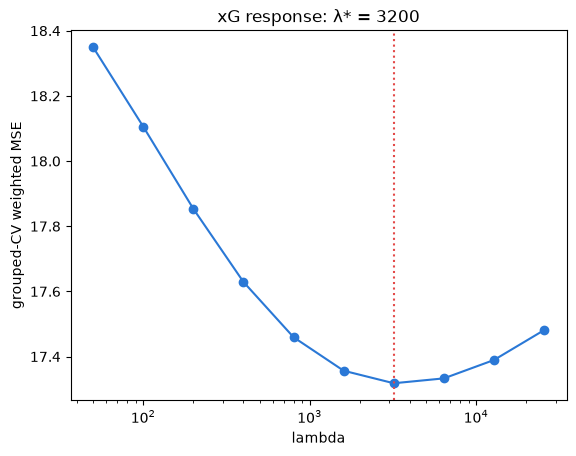

In [2]:
import json
cv = pd.read_parquet(cfg.processed_dir / "cv_curves.parquet")
meta = json.load(open(cfg.processed_dir / "model_meta.json"))
x = cv[cv["response"] == "xg"]
ax = x.plot(x="lambda", y="cv_mse", logx=True, marker="o", color="#2a78d6",
            legend=False, grid=False)
ax.axvline(meta["xg"]["lambda"], color="#e34948", linestyle=":")
ax.set_ylabel("grouped-CV weighted MSE")
ax.set_title(f"xG response: λ* = {meta['xg']['lambda']:g}")
meta["xg"]

In [3]:
ratings = pd.read_parquet(cfg.processed_dir / "ratings.parquet")
cols = ["player", "latest_team", "total_minutes", "rapm_xg",
        "rapm_xg_lo", "rapm_xg_hi", "rapm_goals", "naive_gd90"]
ratings.sort_values("rapm_xg", ascending=False).head(20)[cols].round(3)

,player,latest_team,total_minutes,rapm_xg,rapm_xg_lo,rapm_xg_hi,rapm_goals,naive_gd90
474,Bruno Guimarães,Newcastle United,9133,0.327,0.185,0.433,0.162,1.256
538,Kevin Schade,Brentford,5445,0.277,0.155,0.405,0.139,0.817
239,Rodri,Manchester City,4564,0.259,0.134,0.369,0.235,0.555
312,Jacob Murphy,Newcastle United,5314,0.256,0.101,0.411,0.205,0.781
371,William Saliba,Arsenal,9139,0.244,0.159,0.329,0.259,1.047
225,Trent Alexander-Arnold,Liverpool,4617,0.240,0.131,0.376,0.183,0.822
400,Bukayo Saka,Arsenal,7024,0.221,0.097,0.362,0.136,0.286
170,Evanilson,Bournemouth,5201,0.211,0.043,0.330,-0.017,0.226
521,Rúben Dias,Manchester City,7012,0.209,0.078,0.333,0.182,0.377
23,Luis Díaz,Liverpool,5157,0.200,0.062,0.317,0.220,0.979


## How much do the three methods agree?

In [4]:
from scipy.stats import spearmanr

r = ratings.dropna(subset=["naive_gd90"])
methods = {"naive": r["naive_gd90"], "RAPM (goals)": r["rapm_goals"],
           "RAPM (xG)": r["rapm_xg"]}
corr = pd.DataFrame(
    {a: {b: spearmanr(va, vb).statistic for b, vb in methods.items()}
     for a, va in methods.items()}
)
corr.round(2)

,naive,RAPM (goals),RAPM (xG)
naive,1.00,0.71,0.43
RAPM (goals),0.71,1.00,0.64
RAPM (xG),0.43,0.64,1.00


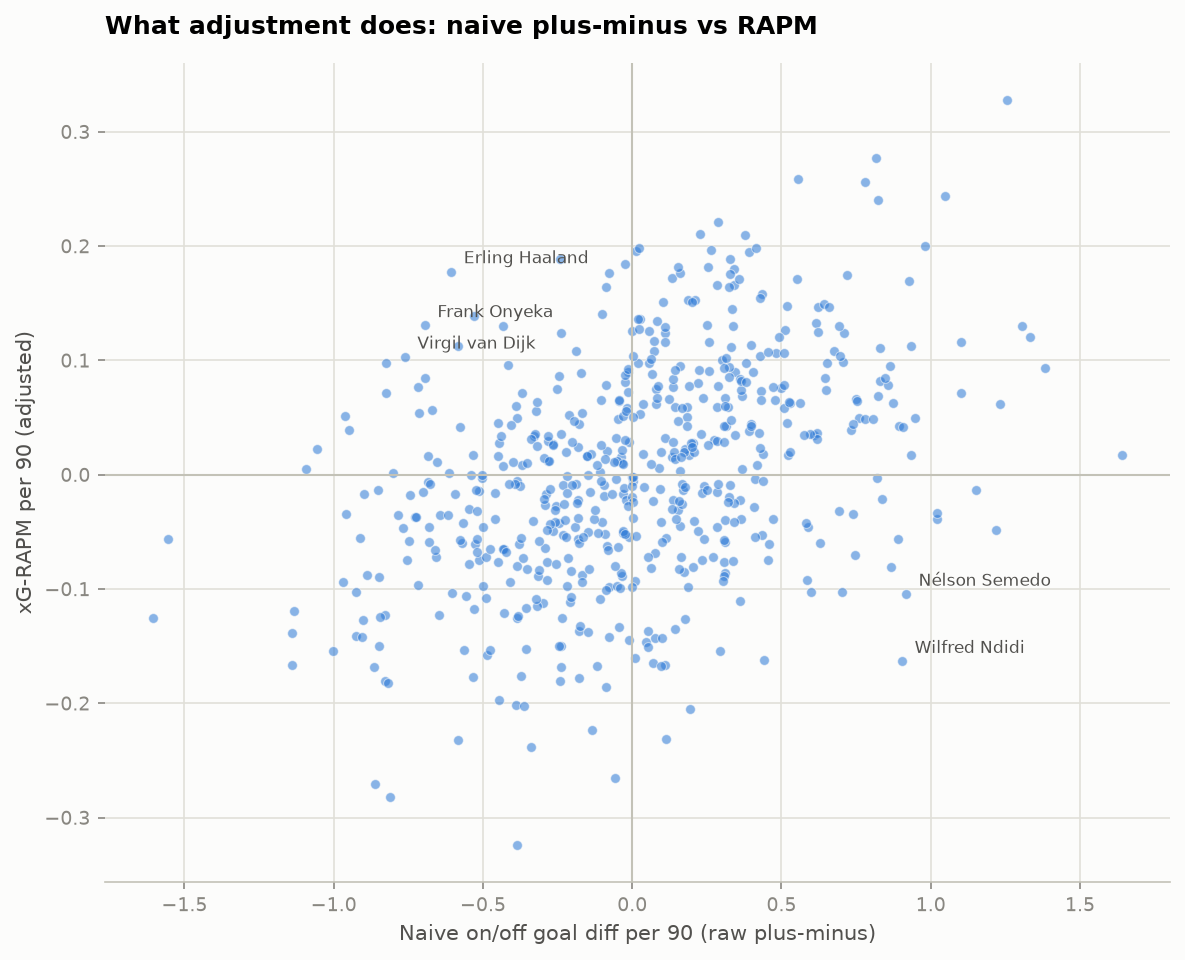

In [5]:
from plimpact.viz import fig_naive_vs_rapm
fig_naive_vs_rapm(ratings, cfg.outputs_dir / "naive_vs_rapm.png")
from IPython.display import Image
Image(str(cfg.outputs_dir / "naive_vs_rapm.png"), width=760)

The two RAPM variants correlate strongly with each other and only moderately
with the naive metric — the adjustment is doing real work. Which response is
more reliable is an empirical question, tested in the next notebook.